# Syndrome vs Ground Truth Analysis

This notebook analyzes the relationship between:
- **Syndrome measurements**: Error detection outcomes from multi-hop paths (encoded transport)
- **Ground truth**: Direct error rate measurements on single-hop edges (data qubit only)

## Analysis Performed
1. **Data Loading & Summary**: Load pickle files and display overview
2. **Symmetry Check**: Compare forward/reverse paths using same edges
3. **Monotonicity Check**: Verify if higher ground truth error → lower P(00)
4. **Per-Edge Analysis**: Infer qubit error rates from syndrome data
5. **Visualization**: Charts comparing predicted vs observed

In [41]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import networkx as nx

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## Configuration

In [42]:
# ============================================================
# CONFIGURATION - Update these paths to your data
# ============================================================

DATA_DIR = Path('../../pickle_files/data_28-01-2026_18-02-41')

MEASUREMENTS_FILE = DATA_DIR / 'measurements.pkl'
GRAPH_FILE = DATA_DIR / 'graph.pkl'
GROUND_TRUTH_FILE = DATA_DIR / 'ground_truth.pkl'

# Verify files exist
print("Checking input files:")
for f in [MEASUREMENTS_FILE, GRAPH_FILE, GROUND_TRUTH_FILE]:
    status = "✓" if f.exists() else "✗"
    print(f"  {status} {f.name}: {f.exists()}")

Checking input files:
  ✓ measurements.pkl: True
  ✓ graph.pkl: True
  ✓ ground_truth.pkl: True


In [43]:
class TimeAwareMeasurement:
    """Data class for syndrome measurements with timing information."""
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

## 1. Load Data

In [44]:
# ============================================================
# LOAD PICKLE FILES
# ============================================================

with open(MEASUREMENTS_FILE, 'rb') as f:
    measurements = pickle.load(f)

with open(GRAPH_FILE, 'rb') as f:
    graph = pickle.load(f)

with open(GROUND_TRUTH_FILE, 'rb') as f:
    ground_truth = pickle.load(f)

print(f"Loaded {len(measurements)} syndrome measurements")
print(f"Loaded graph with {len(graph.nodes)} nodes and {len(graph.edges)} edges")
print(f"Loaded ground truth for {len(ground_truth)} edges")

Loaded 68 syndrome measurements
Loaded graph with 6 nodes and 7 edges
Loaded ground truth for 7 edges


In [45]:
# ============================================================
# PARSE MEASUREMENTS INTO STRUCTURED FORMAT
# ============================================================

def parse_measurements(measurements):
    """
    Parse measurement objects into a structured list of dictionaries.
    
    Returns list of dicts with keys:
        - path_edges: list of edge tuples
        - histogram: numpy array of counts [00, 01, 10, 11]
        - code_type: '313_X' (bit) or '313_Z' (phase)
        - total_shots: sum of histogram
        - probabilities: normalized histogram
    """
    parsed = []
    for m in measurements:
        hist = np.array(m.histogram)
        total = hist.sum()
        parsed.append({
            'path_edges': m.path_edges,
            'histogram': hist,
            'code_type': m.code_type,
            'total_shots': total,
            'probabilities': hist / total if total > 0 else hist,
            'P_00': hist[0] / total if total > 0 else 0,
            'P_01': hist[1] / total if total > 0 else 0,
            'P_10': hist[2] / total if total > 0 else 0,
            'P_11': hist[3] / total if total > 0 else 0,
        })
    return parsed

parsed_measurements = parse_measurements(measurements)

# Separate bit and phase syndrome measurements
bit_measurements = [m for m in parsed_measurements if m['code_type'] == '313_X']
phase_measurements = [m for m in parsed_measurements if m['code_type'] == '313_Z']

print(f"Bit-flip syndrome measurements: {len(bit_measurements)}")
print(f"Phase-flip syndrome measurements: {len(phase_measurements)}")

Bit-flip syndrome measurements: 34
Phase-flip syndrome measurements: 34


## 2. Data Summary

In [46]:
# ============================================================
# GROUND TRUTH SUMMARY
# ============================================================

print("=" * 60)
print("GROUND TRUTH (Single-Edge, Data Qubit Only)")
print("=" * 60)

gt_data = []
for edge, rates in sorted(ground_truth.items()):
    gt_data.append({
        'Edge': f"{edge[0]}→{edge[1]}",
        'edge_tuple': edge,
        'p_bit_flip': rates['p_bit_flip'],
        'p_phase_flip': rates['p_phase_flip'],
    })

gt_df = pd.DataFrame(gt_data)
gt_df_display = gt_df[['Edge', 'p_bit_flip', 'p_phase_flip']].copy()
gt_df_display['p_bit_flip'] = gt_df_display['p_bit_flip'].apply(lambda x: f"{x*100:.2f}%")
gt_df_display['p_phase_flip'] = gt_df_display['p_phase_flip'].apply(lambda x: f"{x*100:.2f}%")
print(gt_df_display.to_string(index=False))

GROUND TRUTH (Single-Edge, Data Qubit Only)
Edge p_bit_flip p_phase_flip
 0→1      4.30%        5.13%
 0→3      4.42%        4.76%
 1→2      4.15%        5.69%
 1→4     50.27%       48.61%
 2→5      2.88%        3.64%
 3→4      7.06%        7.10%
 4→5      4.88%        4.91%


In [47]:
# ============================================================
# SYNDROME MEASUREMENTS SUMMARY
# ============================================================

def edges_to_path_str(edges):
    """Convert list of edge tuples to path string like '0→1→2'"""
    if not edges:
        return ""
    nodes = [edges[0][0]] + [e[1] for e in edges]
    return "→".join(map(str, nodes))

def get_canonical_edges(edges):
    """Get sorted edge tuples for comparison (ignoring direction)"""
    return tuple(sorted([tuple(sorted(e)) for e in edges]))

print("\n" + "=" * 60)
print("SYNDROME MEASUREMENTS (Bit-Flip)")
print("=" * 60)

syndrome_data = []
for m in bit_measurements:
    path_str = edges_to_path_str(m['path_edges'])
    edges_str = " + ".join([f"({e[0]},{e[1]})" for e in m['path_edges']])
    syndrome_data.append({
        'Path': path_str,
        'Edges': edges_str,
        'path_edges': m['path_edges'],
        'canonical_edges': get_canonical_edges(m['path_edges']),
        'P(00)': m['P_00'],
        'P(01)': m['P_01'],
        'P(10)': m['P_10'],
        'P(11)': m['P_11'],
        'Total Error': 1 - m['P_00'],
    })

syndrome_df = pd.DataFrame(syndrome_data)

# Display formatted
display_df = syndrome_df[['Path', 'P(00)', 'P(01)', 'P(10)', 'P(11)', 'Total Error']].copy()
for col in ['P(00)', 'P(01)', 'P(10)', 'P(11)', 'Total Error']:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.1f}%")
print(display_df.to_string(index=False))


SYNDROME MEASUREMENTS (Bit-Flip)
 Path P(00) P(01) P(10) P(11) Total Error
  0→1 85.5%  4.1%  5.8%  4.6%       14.5%
0→1→2 74.8%  7.7%  9.8%  7.8%       25.2%
  0→3 81.0%  6.1%  7.4%  5.6%       19.0%
0→3→4 66.8% 10.9% 11.4% 10.8%       33.2%
0→1→4 26.2% 24.4% 24.3% 25.0%       73.8%
  1→0 84.6%  4.8%  6.0%  4.5%       15.4%
  1→2 84.5%  4.4%  7.2%  3.9%       15.5%
1→4→3 25.5% 24.8% 24.7% 25.0%       74.5%
1→0→3 71.7%  9.1% 11.2%  8.1%       28.3%
  1→4 25.0% 24.6% 25.9% 24.5%       75.0%
1→4→5 24.8% 24.4% 26.5% 24.3%       75.2%
1→2→5 78.1%  8.2%  7.7%  6.0%       21.9%
2→1→0 74.6%  8.5%  9.1%  7.8%       25.4%
  2→1 84.4%  5.0%  6.2%  4.5%       15.6%
2→5→4 72.0%  8.0% 11.0%  8.9%       28.0%
2→1→4 25.7% 24.5% 25.6% 24.2%       74.3%
  2→5 87.3%  4.7%  4.2%  3.9%       12.7%
  3→0 84.3%  4.4%  7.4%  3.8%       15.7%
3→4→1 24.7% 24.5% 25.1% 25.7%       75.3%
3→0→1 75.6%  9.0%  7.9%  7.5%       24.4%
  3→4 73.9%  8.1%  9.6%  8.4%       26.1%
3→4→5 68.7%  8.9% 13.1%  9.3%       31.3%


## 3. Symmetry Analysis

Compare paths that use the same edges but in reverse order. These should have similar syndrome distributions.

In [48]:
# ============================================================
# SYMMETRY ANALYSIS: Forward vs Reverse Paths
# ============================================================

def find_symmetric_pairs(syndrome_df):
    """
    Find pairs of paths that use the same edges in reverse order.
    """
    # Group by canonical edges
    groups = defaultdict(list)
    for idx, row in syndrome_df.iterrows():
        groups[row['canonical_edges']].append(row)
    
    # Find pairs
    pairs = []
    for canonical, rows in groups.items():
        if len(rows) == 2:
            pairs.append((rows[0], rows[1]))
    
    return pairs

symmetric_pairs = find_symmetric_pairs(syndrome_df)

print("=" * 70)
print("SYMMETRY ANALYSIS: Same Edges, Reverse Direction")
print("=" * 70)
print(f"Found {len(symmetric_pairs)} symmetric path pairs\n")

symmetry_results = []
for p1, p2 in symmetric_pairs:
    delta = abs(p1['P(00)'] - p2['P(00)'])
    symmetry_results.append({
        'Path 1': p1['Path'],
        'P(00) 1': p1['P(00)'],
        'Path 2': p2['Path'],
        'P(00) 2': p2['P(00)'],
        'Δ P(00)': delta,
        'Symmetric': '✓' if delta < 0.05 else '✗',
    })

symmetry_df = pd.DataFrame(symmetry_results)
symmetry_df = symmetry_df.sort_values('Δ P(00)')

# Format for display
sym_display = symmetry_df.copy()
for col in ['P(00) 1', 'P(00) 2', 'Δ P(00)']:
    sym_display[col] = sym_display[col].apply(lambda x: f"{x*100:.1f}%")
print(sym_display.to_string(index=False))

# Summary
avg_delta = symmetry_df['Δ P(00)'].mean()
max_delta = symmetry_df['Δ P(00)'].max()
symmetric_count = (symmetry_df['Δ P(00)'] < 0.05).sum()

print(f"\nSummary:")
print(f"  Average Δ: {avg_delta*100:.2f}%")
print(f"  Max Δ: {max_delta*100:.2f}%")
print(f"  Symmetric pairs (Δ < 5%): {symmetric_count}/{len(symmetric_pairs)}")

SYMMETRY ANALYSIS: Same Edges, Reverse Direction
Found 17 symmetric path pairs

Path 1 P(00) 1 Path 2 P(00) 2 Δ P(00) Symmetric
   3→4   73.9%    4→3   74.0%    0.0%         ✓
 1→4→5   24.8%  5→4→1   24.9%    0.1%         ✓
   1→2   84.5%    2→1   84.4%    0.1%         ✓
 1→2→5   78.1%  5→2→1   77.9%    0.2%         ✓
 0→1→2   74.8%  2→1→0   74.6%    0.2%         ✓
   2→5   87.3%    5→2   87.0%    0.3%         ✓
   1→4   25.0%    4→1   24.6%    0.4%         ✓
 0→1→4   26.2%  4→1→0   25.6%    0.7%         ✓
 2→1→4   25.7%  4→1→2   25.0%    0.7%         ✓
 1→4→3   25.5%  3→4→1   24.7%    0.8%         ✓
   0→1   85.5%    1→0   84.6%    0.9%         ✓
 2→5→4   72.0%  4→5→2   73.6%    1.5%         ✓
   0→3   81.0%    3→0   84.3%    3.4%         ✓
 3→4→5   68.7%  5→4→3   65.2%    3.5%         ✓
 1→0→3   71.7%  3→0→1   75.6%    3.9%         ✓
 0→3→4   66.8%  4→3→0   70.9%    4.1%         ✓
   4→5   81.5%    5→4   75.0%    6.6%         ✗

Summary:
  Average Δ: 1.61%
  Max Δ: 6.57%
  Symmetric 

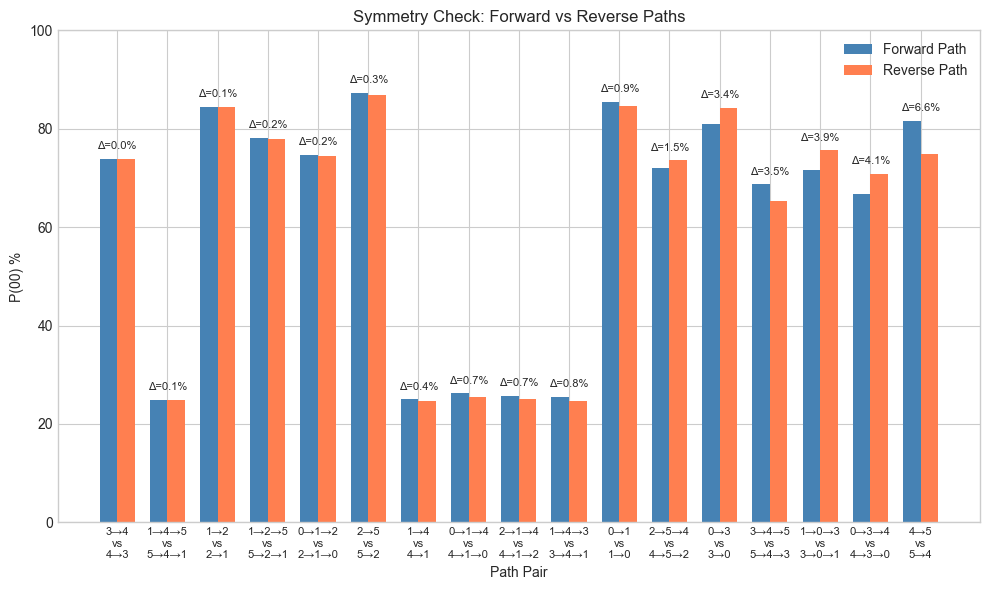

In [49]:
# ============================================================
# SYMMETRY VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(symmetry_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], symmetry_df['P(00) 1'] * 100, 
               width, label='Forward Path', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], symmetry_df['P(00) 2'] * 100, 
               width, label='Reverse Path', color='coral')

ax.set_xlabel('Path Pair')
ax.set_ylabel('P(00) %')
ax.set_title('Symmetry Check: Forward vs Reverse Paths')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Path 1']}\nvs\n{r['Path 2']}" 
                    for _, r in symmetry_df.iterrows()], fontsize=8)
ax.legend()
ax.set_ylim(0, 100)

# Add delta annotations
for i, (_, row) in enumerate(symmetry_df.iterrows()):
    delta = row['Δ P(00)'] * 100
    max_val = max(row['P(00) 1'], row['P(00) 2']) * 100
    ax.annotate(f'Δ={delta:.1f}%', xy=(i, max_val + 2), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Monotonicity Analysis

Check if higher ground truth error correlates with lower P(00) in syndromes.

In [50]:
# ============================================================
# COMPUTE GROUND TRUTH SUM FOR EACH PATH
# ============================================================

def get_edge_ground_truth(edge, ground_truth):
    """
    Get ground truth for an edge (handles both directions).
    """
    sorted_edge = tuple(sorted(edge))
    if sorted_edge in ground_truth:
        return ground_truth[sorted_edge]
    return None

def compute_path_ground_truth(path_edges, ground_truth):
    """
    Compute total ground truth error for a path (sum of edge errors).
    """
    total_bit = 0
    total_phase = 0
    for edge in path_edges:
        gt = get_edge_ground_truth(edge, ground_truth)
        if gt:
            total_bit += gt['p_bit_flip']
            total_phase += gt['p_phase_flip']
    return total_bit, total_phase

# Add ground truth sums to syndrome dataframe
gt_sums = []
for _, row in syndrome_df.iterrows():
    bit_sum, phase_sum = compute_path_ground_truth(row['path_edges'], ground_truth)
    gt_sums.append({'GT_bit_sum': bit_sum, 'GT_phase_sum': phase_sum})

syndrome_df = pd.concat([syndrome_df, pd.DataFrame(gt_sums)], axis=1)

print("=" * 70)
print("MONOTONICITY ANALYSIS: Ground Truth Sum vs P(00)")
print("=" * 70)

# Sort by GT sum to check monotonicity
mono_df = syndrome_df[['Path', 'Edges', 'GT_bit_sum', 'P(00)']].copy()
mono_df = mono_df.sort_values('GT_bit_sum')

# Format for display
mono_display = mono_df.copy()
mono_display['GT_bit_sum'] = mono_display['GT_bit_sum'].apply(lambda x: f"{x*100:.1f}%")
mono_display['P(00)'] = mono_display['P(00)'].apply(lambda x: f"{x*100:.1f}%")
print(mono_display.to_string(index=False))

MONOTONICITY ANALYSIS: Ground Truth Sum vs P(00)
 Path         Edges GT_bit_sum P(00)
  2→5         (2,5)       2.9% 87.3%
  5→2         (5,2)       2.9% 87.0%
  2→1         (2,1)       4.2% 84.4%
  1→2         (1,2)       4.2% 84.5%
  1→0         (1,0)       4.3% 84.6%
  0→1         (0,1)       4.3% 85.5%
  0→3         (0,3)       4.4% 81.0%
  3→0         (3,0)       4.4% 84.3%
  5→4         (5,4)       4.9% 75.0%
  4→5         (4,5)       4.9% 81.5%
5→2→1 (5,2) + (2,1)       7.0% 77.9%
1→2→5 (1,2) + (2,5)       7.0% 78.1%
  4→3         (4,3)       7.1% 74.0%
  3→4         (3,4)       7.1% 73.9%
2→5→4 (2,5) + (5,4)       7.8% 72.0%
4→5→2 (4,5) + (5,2)       7.8% 73.6%
0→1→2 (0,1) + (1,2)       8.4% 74.8%
2→1→0 (2,1) + (1,0)       8.4% 74.6%
3→0→1 (3,0) + (0,1)       8.7% 75.6%
1→0→3 (1,0) + (0,3)       8.7% 71.7%
4→3→0 (4,3) + (3,0)      11.5% 70.9%
0→3→4 (0,3) + (3,4)      11.5% 66.8%
5→4→3 (5,4) + (4,3)      11.9% 65.2%
3→4→5 (3,4) + (4,5)      11.9% 68.7%
  4→1         (4,1)      5

In [51]:
# ============================================================
# MONOTONICITY CORRELATION
# ============================================================

correlation = syndrome_df['GT_bit_sum'].corr(syndrome_df['P(00)'])

print(f"\nCorrelation between GT_bit_sum and P(00): {correlation:.3f}")
print(f"Expected: negative (higher error → lower P(00))")
print(f"Result: {'✓ Correct direction' if correlation < 0 else '✗ Unexpected direction'}")

# Check strict monotonicity
sorted_by_gt = syndrome_df.sort_values('GT_bit_sum')
p00_values = sorted_by_gt['P(00)'].values
violations = sum(1 for i in range(len(p00_values)-1) if p00_values[i] < p00_values[i+1])
print(f"\nMonotonicity violations: {violations}/{len(p00_values)-1}")


Correlation between GT_bit_sum and P(00): -0.990
Expected: negative (higher error → lower P(00))
Result: ✓ Correct direction

Monotonicity violations: 15/33


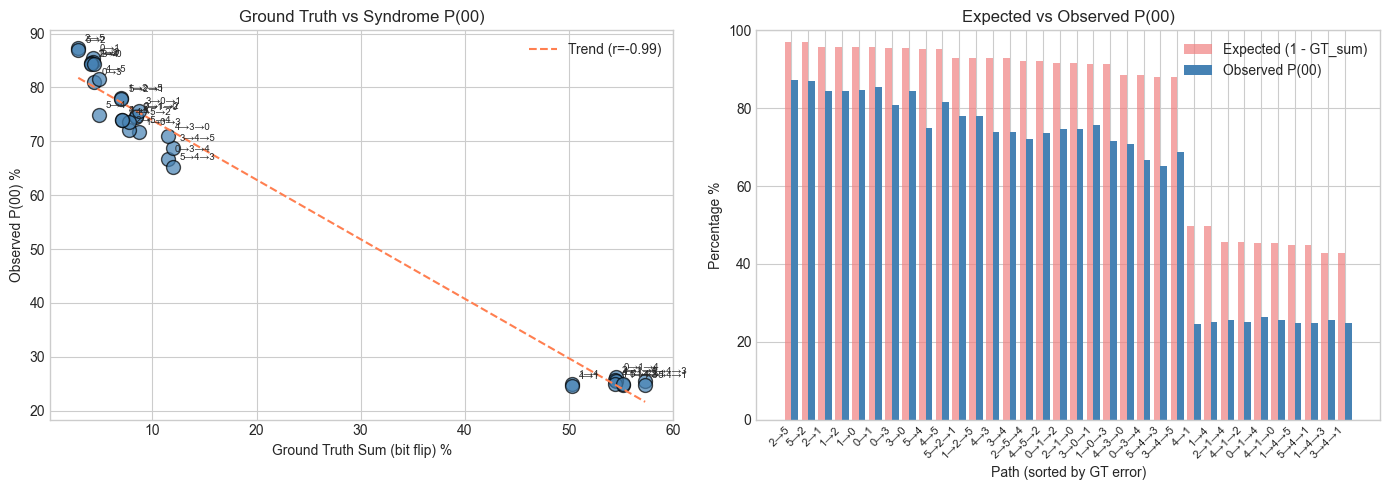

In [52]:
# ============================================================
# MONOTONICITY VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot with regression line
ax1 = axes[0]
ax1.scatter(syndrome_df['GT_bit_sum'] * 100, syndrome_df['P(00)'] * 100, 
            s=100, alpha=0.7, c='steelblue', edgecolors='black')

# Add labels for each point
for _, row in syndrome_df.iterrows():
    ax1.annotate(row['Path'], 
                 (row['GT_bit_sum'] * 100, row['P(00)'] * 100),
                 textcoords="offset points", xytext=(5, 5), fontsize=7)

# Regression line
z = np.polyfit(syndrome_df['GT_bit_sum'] * 100, syndrome_df['P(00)'] * 100, 1)
p = np.poly1d(z)
x_line = np.linspace(syndrome_df['GT_bit_sum'].min() * 100, 
                     syndrome_df['GT_bit_sum'].max() * 100, 100)
ax1.plot(x_line, p(x_line), "--", color='coral', label=f'Trend (r={correlation:.2f})')

ax1.set_xlabel('Ground Truth Sum (bit flip) %')
ax1.set_ylabel('Observed P(00) %')
ax1.set_title('Ground Truth vs Syndrome P(00)')
ax1.legend()

# Plot 2: Bar chart sorted by GT sum
ax2 = axes[1]
sorted_df = syndrome_df.sort_values('GT_bit_sum')

x = range(len(sorted_df))
width = 0.4

# Normalize GT sum to similar scale as P(00) for visualization
# Using (1 - GT_sum) to make it comparable to P(00)
expected_p00 = 1 - sorted_df['GT_bit_sum']

bars1 = ax2.bar([i - width/2 for i in x], expected_p00 * 100, 
                width, label='Expected (1 - GT_sum)', color='lightcoral', alpha=0.7)
bars2 = ax2.bar([i + width/2 for i in x], sorted_df['P(00)'] * 100, 
                width, label='Observed P(00)', color='steelblue')

ax2.set_xlabel('Path (sorted by GT error)')
ax2.set_ylabel('Percentage %')
ax2.set_title('Expected vs Observed P(00)')
ax2.set_xticks(x)
ax2.set_xticklabels(sorted_df['Path'], rotation=45, ha='right', fontsize=8)
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 5. Per-Edge Syndrome Analysis

Analyze which edges appear in paths with high/low syndrome success rates.

In [53]:
# ============================================================
# PER-EDGE SYNDROME STATISTICS
# ============================================================

def compute_edge_statistics(syndrome_df, ground_truth):
    """
    Compute average P(00) for paths containing each edge.
    """
    edge_stats = defaultdict(lambda: {'p00_values': [], 'paths': []})
    
    for _, row in syndrome_df.iterrows():
        for edge in row['path_edges']:
            sorted_edge = tuple(sorted(edge))
            edge_stats[sorted_edge]['p00_values'].append(row['P(00)'])
            edge_stats[sorted_edge]['paths'].append(row['Path'])
    
    results = []
    for edge, stats in sorted(edge_stats.items()):
        gt = ground_truth.get(edge, {})
        results.append({
            'Edge': f"{edge[0]}↔{edge[1]}",
            'edge_tuple': edge,
            'GT p_bit': gt.get('p_bit_flip', None),
            'Avg P(00)': np.mean(stats['p00_values']),
            'Min P(00)': np.min(stats['p00_values']),
            'Max P(00)': np.max(stats['p00_values']),
            'Num Paths': len(stats['p00_values']),
        })
    
    return pd.DataFrame(results)

edge_stats_df = compute_edge_statistics(syndrome_df, ground_truth)

print("=" * 70)
print("PER-EDGE STATISTICS")
print("=" * 70)

# Format for display
edge_display = edge_stats_df.copy()
for col in ['GT p_bit', 'Avg P(00)', 'Min P(00)', 'Max P(00)']:
    edge_display[col] = edge_display[col].apply(lambda x: f"{x*100:.1f}%" if x else "N/A")
print(edge_display[['Edge', 'GT p_bit', 'Avg P(00)', 'Min P(00)', 'Max P(00)', 'Num Paths']].to_string(index=False))

PER-EDGE STATISTICS
Edge GT p_bit Avg P(00) Min P(00) Max P(00)  Num Paths
 0↔1     4.3%     64.8%     25.6%     85.5%          8
 0↔3     4.4%     75.0%     66.8%     84.3%          6
 1↔2     4.2%     65.6%     25.0%     84.5%          8
 1↔4    50.3%     25.2%     24.6%     26.2%         10
 2↔5     2.9%     79.3%     72.0%     87.3%          6
 3↔4     7.1%     58.7%     24.7%     74.0%          8
 4↔5     4.9%     60.7%     24.8%     81.5%          8


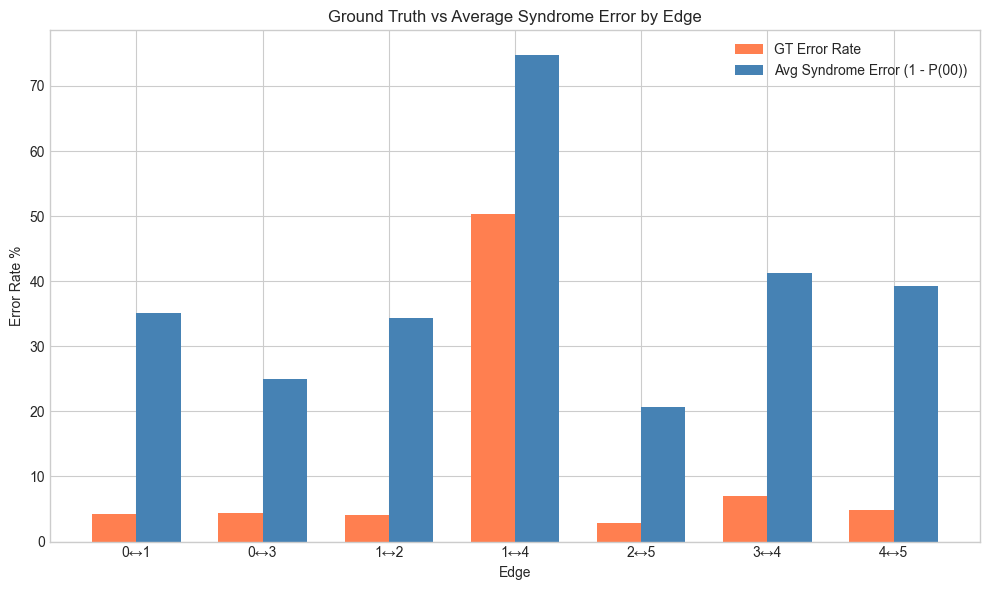

In [54]:
# ============================================================
# EDGE QUALITY COMPARISON
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

edges = edge_stats_df['Edge'].values
x = range(len(edges))
width = 0.35

gt_errors = edge_stats_df['GT p_bit'].values * 100
avg_p00 = edge_stats_df['Avg P(00)'].values * 100

# Plot GT error (inverted for comparison)
ax.bar([i - width/2 for i in x], gt_errors, width, 
       label='GT Error Rate', color='coral')
ax.bar([i + width/2 for i in x], 100 - avg_p00, width,
       label='Avg Syndrome Error (1 - P(00))', color='steelblue')

ax.set_xlabel('Edge')
ax.set_ylabel('Error Rate %')
ax.set_title('Ground Truth vs Average Syndrome Error by Edge')
ax.set_xticks(x)
ax.set_xticklabels(edges)
ax.legend()

plt.tight_layout()
plt.show()

## 6. Syndrome Distribution Analysis

Analyze the distribution of syndrome outcomes (00, 01, 10, 11) to infer qubit-level errors.

In [55]:
# ============================================================
# SYNDROME OUTCOME ASYMMETRY ANALYSIS
# ============================================================

print("=" * 70)
print("SYNDROME ASYMMETRY ANALYSIS")
print("=" * 70)
print("\nUnder uniform error model, P(01) = P(10) = P(11).")
print("Asymmetry indicates different error rates on encoding qubits.\n")

asymmetry_data = []
for _, row in syndrome_df.iterrows():
    p01, p10, p11 = row['P(01)'], row['P(10)'], row['P(11)']
    
    # Compute asymmetry metrics
    asymmetry_01_10 = abs(p01 - p10) / max(p01, p10) if max(p01, p10) > 0 else 0
    
    asymmetry_data.append({
        'Path': row['Path'],
        'P(01)': p01,
        'P(10)': p10,
        'P(11)': p11,
        '|P(01)-P(10)|': abs(p01 - p10),
        'Dominant': 'enc1' if p01 > p10 else ('enc0' if p10 > p01 else 'equal'),
    })

asymmetry_df = pd.DataFrame(asymmetry_data)

# Format for display
asym_display = asymmetry_df.copy()
for col in ['P(01)', 'P(10)', 'P(11)', '|P(01)-P(10)|']:
    asym_display[col] = asym_display[col].apply(lambda x: f"{x*100:.1f}%")
print(asym_display.to_string(index=False))

SYNDROME ASYMMETRY ANALYSIS

Under uniform error model, P(01) = P(10) = P(11).
Asymmetry indicates different error rates on encoding qubits.

 Path P(01) P(10) P(11) |P(01)-P(10)| Dominant
  0→1  4.1%  5.8%  4.6%          1.7%     enc0
0→1→2  7.7%  9.8%  7.8%          2.1%     enc0
  0→3  6.1%  7.4%  5.6%          1.3%     enc0
0→3→4 10.9% 11.4% 10.8%          0.5%     enc0
0→1→4 24.4% 24.3% 25.0%          0.1%     enc1
  1→0  4.8%  6.0%  4.5%          1.1%     enc0
  1→2  4.4%  7.2%  3.9%          2.8%     enc0
1→4→3 24.8% 24.7% 25.0%          0.1%     enc1
1→0→3  9.1% 11.2%  8.1%          2.1%     enc0
  1→4 24.6% 25.9% 24.5%          1.3%     enc0
1→4→5 24.4% 26.5% 24.3%          2.1%     enc0
1→2→5  8.2%  7.7%  6.0%          0.5%     enc1
2→1→0  8.5%  9.1%  7.8%          0.5%     enc0
  2→1  5.0%  6.2%  4.5%          1.2%     enc0
2→5→4  8.0% 11.0%  8.9%          3.0%     enc0
2→1→4 24.5% 25.6% 24.2%          1.1%     enc0
  2→5  4.7%  4.2%  3.9%          0.5%     enc1
  3→0  4.4% 

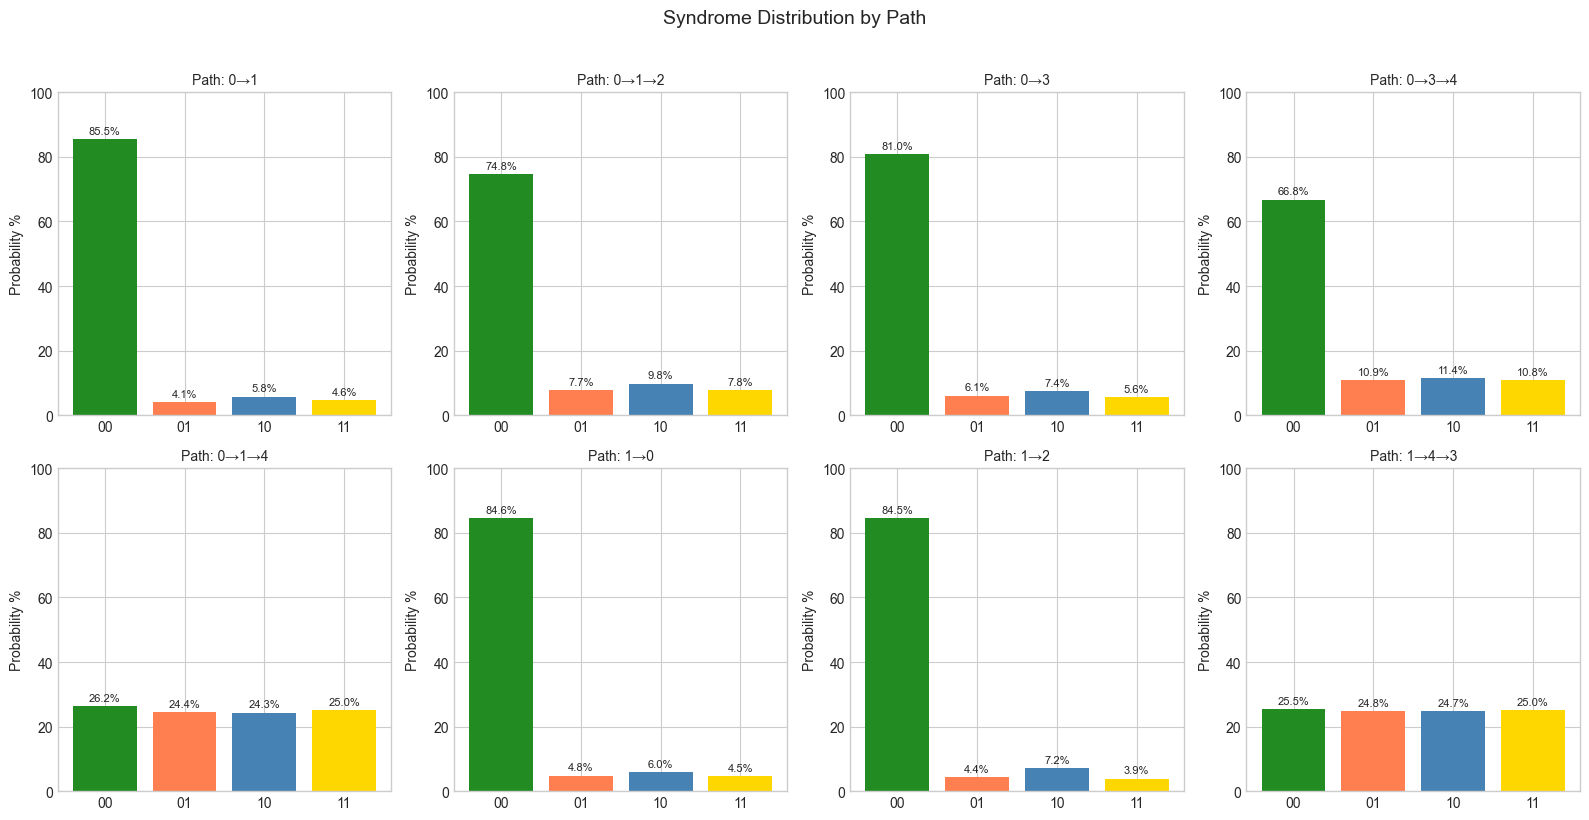

In [56]:
# ============================================================
# SYNDROME DISTRIBUTION VISUALIZATION
# ============================================================

# Select a few representative paths
n_paths = min(8, len(syndrome_df))
sample_df = syndrome_df.head(n_paths)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

syndrome_labels = ['00', '01', '10', '11']
colors = ['forestgreen', 'coral', 'steelblue', 'gold']

for idx, (_, row) in enumerate(sample_df.iterrows()):
    if idx >= len(axes):
        break
    ax = axes[idx]
    probs = [row['P(00)'], row['P(01)'], row['P(10)'], row['P(11)']]
    
    bars = ax.bar(syndrome_labels, [p * 100 for p in probs], color=colors)
    ax.set_title(f"Path: {row['Path']}", fontsize=10)
    ax.set_ylabel('Probability %')
    ax.set_ylim(0, 100)
    
    # Add value labels
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=8)

# Hide unused subplots
for idx in range(n_paths, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Syndrome Distribution by Path', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Predicted vs Observed P(00)

Using the uniform error model to predict P(00) and compare with observations.

In [57]:
# ============================================================
# PREDICTED P(00) UNDER UNIFORM ERROR MODEL
# ============================================================

def predict_p00_uniform(p_eff):
    """
    Predict P(00) under uniform error model.
    P(00) = (1-p)^3 + p^3 where p is effective error rate.
    """
    return (1 - p_eff)**3 + p_eff**3

def compute_effective_error(edge_errors):
    """
    Compute effective error rate for multi-hop path.
    Uses XOR combination: p_eff = p1 + p2 - 2*p1*p2
    """
    p_eff = 0
    for p in edge_errors:
        p_eff = p_eff + p - 2 * p_eff * p
    return p_eff

# Compute predictions
predictions = []
for _, row in syndrome_df.iterrows():
    edge_errors = []
    for edge in row['path_edges']:
        gt = get_edge_ground_truth(edge, ground_truth)
        if gt:
            edge_errors.append(gt['p_bit_flip'])
    
    if edge_errors:
        p_eff = compute_effective_error(edge_errors)
        p00_predicted = predict_p00_uniform(p_eff)
    else:
        p_eff = None
        p00_predicted = None
    
    predictions.append({
        'Path': row['Path'],
        'p_eff': p_eff,
        'Predicted P(00)': p00_predicted,
        'Observed P(00)': row['P(00)'],
        'Residual': row['P(00)'] - p00_predicted if p00_predicted else None,
    })

pred_df = pd.DataFrame(predictions)

print("=" * 70)
print("PREDICTED vs OBSERVED P(00) (Uniform Error Model)")
print("=" * 70)

# Format for display
pred_display = pred_df.copy()
for col in ['p_eff', 'Predicted P(00)', 'Observed P(00)', 'Residual']:
    pred_display[col] = pred_display[col].apply(
        lambda x: f"{x*100:.1f}%" if x is not None else "N/A"
    )
print(pred_display.to_string(index=False))

# Summary statistics
valid_residuals = pred_df['Residual'].dropna()
print(f"\nResidual Statistics:")
print(f"  Mean: {valid_residuals.mean()*100:.2f}%")
print(f"  Std:  {valid_residuals.std()*100:.2f}%")
print(f"  RMSE: {np.sqrt((valid_residuals**2).mean())*100:.2f}%")

PREDICTED vs OBSERVED P(00) (Uniform Error Model)
 Path p_eff Predicted P(00) Observed P(00) Residual
  0→1  4.3%           87.7%          85.5%    -2.1%
0→1→2  8.1%           77.7%          74.8%    -2.9%
  0→3  4.4%           87.3%          81.0%    -6.4%
0→3→4 10.9%           71.0%          66.8%    -4.2%
0→1→4 50.2%           25.0%          26.2%     1.2%
  1→0  4.3%           87.7%          84.6%    -3.0%
  1→2  4.2%           88.1%          84.5%    -3.6%
1→4→3 50.2%           25.0%          25.5%     0.5%
1→0→3  8.3%           77.1%          71.7%    -5.4%
  1→4 50.3%           25.0%          25.0%    -0.0%
1→4→5 50.2%           25.0%          24.8%    -0.2%
1→2→5  6.8%           81.0%          78.1%    -2.9%
2→1→0  8.1%           77.7%          74.6%    -3.1%
  2→1  4.2%           88.1%          84.4%    -3.7%
2→5→4  7.5%           79.2%          72.0%    -7.2%
2→1→4 50.2%           25.0%          25.7%     0.7%
  2→5  2.9%           91.6%          87.3%    -4.3%
  3→0  4.4%   

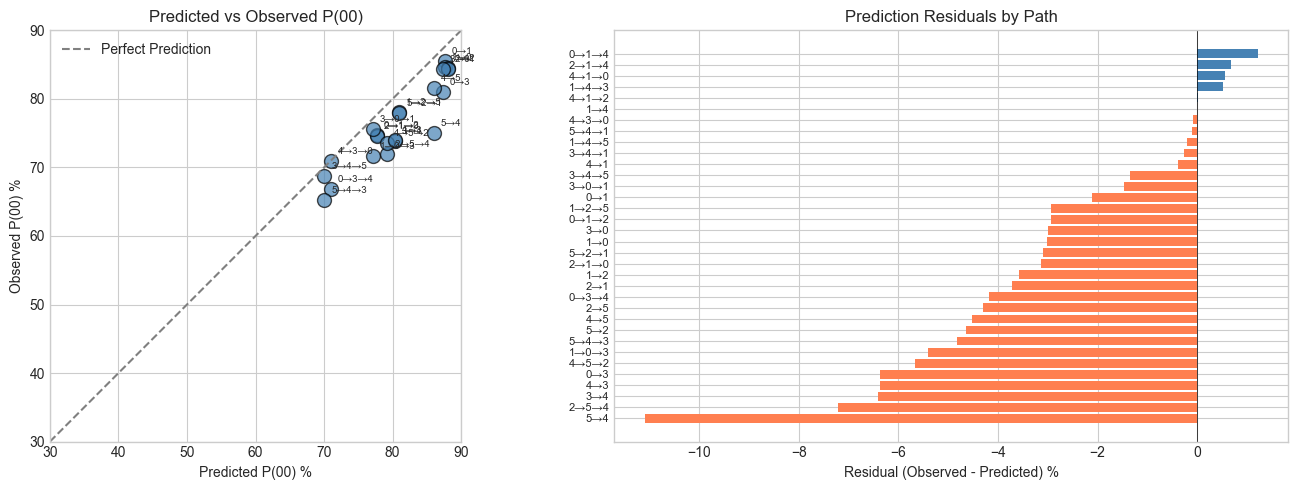

In [58]:
# ============================================================
# PREDICTED vs OBSERVED VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_pred = pred_df.dropna()

# Plot 1: Scatter plot
ax1 = axes[0]
ax1.scatter(valid_pred['Predicted P(00)'] * 100, valid_pred['Observed P(00)'] * 100,
            s=100, alpha=0.7, c='steelblue', edgecolors='black')

# Perfect prediction line
lims = [30, 90]
ax1.plot(lims, lims, '--', color='gray', label='Perfect Prediction')

# Add labels
for _, row in valid_pred.iterrows():
    ax1.annotate(row['Path'],
                 (row['Predicted P(00)'] * 100, row['Observed P(00)'] * 100),
                 textcoords="offset points", xytext=(5, 5), fontsize=7)

ax1.set_xlabel('Predicted P(00) %')
ax1.set_ylabel('Observed P(00) %')
ax1.set_title('Predicted vs Observed P(00)')
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.legend()
ax1.set_aspect('equal')

# Plot 2: Residual bar chart
ax2 = axes[1]
sorted_pred = valid_pred.sort_values('Residual')
colors = ['coral' if r < 0 else 'steelblue' for r in sorted_pred['Residual']]
ax2.barh(range(len(sorted_pred)), sorted_pred['Residual'] * 100, color=colors)
ax2.set_yticks(range(len(sorted_pred)))
ax2.set_yticklabels(sorted_pred['Path'], fontsize=8)
ax2.set_xlabel('Residual (Observed - Predicted) %')
ax2.set_title('Prediction Residuals by Path')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 8. Summary Report

In [59]:
# ============================================================
# SUMMARY REPORT
# ============================================================

print("="*70)
print("ANALYSIS SUMMARY REPORT")
print("="*70)

print("\n1. DATA OVERVIEW")
print(f"   - Syndrome measurements: {len(bit_measurements)} (bit-flip)")
print(f"   - Ground truth edges: {len(ground_truth)}")
print(f"   - Network: {len(graph.nodes)} nodes, {len(graph.edges)} edges")

print("\n2. SYMMETRY CHECK")
if len(symmetry_df) > 0:
    avg_delta = symmetry_df['Δ P(00)'].mean()
    symmetric_count = (symmetry_df['Δ P(00)'] < 0.05).sum()
    print(f"   - Average Δ between forward/reverse paths: {avg_delta*100:.2f}%")
    print(f"   - Symmetric pairs (Δ < 5%): {symmetric_count}/{len(symmetry_df)}")
    print(f"   - Verdict: {'✓ PASS' if avg_delta < 0.05 else '⚠ PARTIAL'}")

print("\n3. MONOTONICITY CHECK")
print(f"   - Correlation (GT sum vs P(00)): {correlation:.3f}")
print(f"   - Expected: negative correlation")
print(f"   - Verdict: {'✓ PASS' if correlation < -0.3 else '⚠ WEAK' if correlation < 0 else '✗ FAIL'}")

print("\n4. PREDICTION ACCURACY (Uniform Error Model)")
if len(valid_residuals) > 0:
    rmse = np.sqrt((valid_residuals**2).mean())
    mean_residual = valid_residuals.mean()
    print(f"   - Mean residual: {mean_residual*100:+.2f}%")
    print(f"   - RMSE: {rmse*100:.2f}%")
    print(f"   - Verdict: {'✓ GOOD' if rmse < 0.10 else '⚠ MODERATE' if rmse < 0.15 else '✗ POOR'}")

print("\n5. KEY FINDINGS")
# Find best and worst edges
best_edge = gt_df.loc[gt_df['p_bit_flip'].idxmin()]
worst_edge = gt_df.loc[gt_df['p_bit_flip'].idxmax()]
print(f"   - Best edge: {best_edge['Edge']} ({best_edge['p_bit_flip']*100:.2f}% error)")
print(f"   - Worst edge: {worst_edge['Edge']} ({worst_edge['p_bit_flip']*100:.2f}% error)")

# Find best and worst paths
best_path = syndrome_df.loc[syndrome_df['P(00)'].idxmax()]
worst_path = syndrome_df.loc[syndrome_df['P(00)'].idxmin()]
print(f"   - Best path: {best_path['Path']} (P(00)={best_path['P(00)']*100:.1f}%)")
print(f"   - Worst path: {worst_path['Path']} (P(00)={worst_path['P(00)']*100:.1f}%)")

print("\n" + "="*70)

ANALYSIS SUMMARY REPORT

1. DATA OVERVIEW
   - Syndrome measurements: 34 (bit-flip)
   - Ground truth edges: 7
   - Network: 6 nodes, 7 edges

2. SYMMETRY CHECK
   - Average Δ between forward/reverse paths: 1.61%
   - Symmetric pairs (Δ < 5%): 16/17
   - Verdict: ✓ PASS

3. MONOTONICITY CHECK
   - Correlation (GT sum vs P(00)): -0.990
   - Expected: negative correlation
   - Verdict: ✓ PASS

4. PREDICTION ACCURACY (Uniform Error Model)
   - Mean residual: -2.92%
   - RMSE: 4.03%
   - Verdict: ✓ GOOD

5. KEY FINDINGS
   - Best edge: 2→5 (2.88% error)
   - Worst edge: 1→4 (50.27% error)
   - Best path: 2→5 (P(00)=87.3%)
   - Worst path: 4→1 (P(00)=24.6%)



## 9. Export Results (Optional)

In [60]:
# ============================================================
# EXPORT ANALYSIS RESULTS
# ============================================================

EXPORT_RESULTS = False  # Set to True to export

if EXPORT_RESULTS:
    output_dir = DATA_DIR / 'analysis'
    output_dir.mkdir(exist_ok=True)
    
    # Export dataframes
    syndrome_df.to_csv(output_dir / 'syndrome_analysis.csv', index=False)
    symmetry_df.to_csv(output_dir / 'symmetry_analysis.csv', index=False)
    pred_df.to_csv(output_dir / 'prediction_analysis.csv', index=False)
    edge_stats_df.to_csv(output_dir / 'edge_statistics.csv', index=False)
    
    print(f"Results exported to {output_dir}")
else:
    print("Set EXPORT_RESULTS = True to export analysis results to CSV files.")

Set EXPORT_RESULTS = True to export analysis results to CSV files.
